In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical

In [ ]:
emotion_to_label = {
    "angry":0,
    "disgust":1,
    "fear":2,
    "happy":3,
    "neutral":4,
    "sad":5,
    "surprise":6
}

In [ ]:
label_to_emotion = {
    v:k for k,v in emotion_to_label.items()
}

In [ ]:
def load_images(data_dir):

    images = []
    labels = []

    for emotion in os.listdir(data_dir):

        emotion_folder = os.path.join(
            data_dir,
            emotion
        )

        if not os.path.isdir(emotion_folder):
            continue

        label = emotion_to_label[emotion]

        for file in os.listdir(emotion_folder):

            image_path = os.path.join(
                emotion_folder,
                file
            )

            image = cv2.imread(
                image_path,
                cv2.IMREAD_GRAYSCALE
            )

            images.append(image)
            labels.append(label)

    return np.array(images), np.array(labels)

In [ ]:
!kaggle datasets download -d msambare/fer2013
!unzip -q fer2013.zip

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
fer2013.zip: Skipping, found more recently modified local copy (use --force to force download)
replace test/angry/PrivateTest_10131363.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test/angry/PrivateTest_10304478.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test/angry/PrivateTest_1054527.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
base = "/content/drive/MyDrive/emotion_sentiment_fusion_detector/data/fer2013"

print(os.path.exists(base))
print(os.path.exists(base + "/train"))
print(os.path.exists(base + "/test"))

True
True
False


In [ ]:
X_train_full, y_train_full = load_images("train")
X_test, y_test = load_images("test")

print(X_train_full.shape)
print(X_test.shape)

(28709, 48, 48)
(7178, 48, 48)


### Normalize Images

In [ ]:
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
print(X_train_full.min())
print(X_train_full.max())

0.0
1.0


### Channel Dimension

In [ ]:
X_train_full = np.expand_dims(
    X_train_full,
    axis=-1
)

X_test = np.expand_dims(
    X_test,
    axis=-1
)

In [ ]:
print(X_train_full.shape)

(28709, 48, 48, 1)


In [ ]:
print(np.unique(y_train_full))

[0 1 2 3 4 5 6]


### One-hot Encode

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
y_train_full = to_categorical(
    y_train_full,
    num_classes=7
)

y_test = to_categorical(
    y_test,
    num_classes=7
)

In [ ]:
print(y_train_full[0])

[0. 0. 0. 0. 1. 0. 0.]


### Train / Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y_train_full, axis=1)
)

In [ ]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Train: (22967, 48, 48, 1)
Validation: (5742, 48, 48, 1)
Test: (7178, 48, 48, 1)
y_train: (22967, 7)
y_val: (5742, 7)
y_test: (7178, 7)


# Data Preparation Summary

The FER2013 dataset was loaded and preprocessed for CNN training.

## Steps Completed

1. Loaded grayscale facial emotion images.
2. Encoded emotion labels numerically.
3. Normalized pixel values from [0,255] to [0,1].
4. Added channel dimension for CNN compatibility.
5. One-hot encoded emotion labels.
6. Created train, validation, and test splits.

## Dataset Shapes

### Training Set
- Images: 22,967
- Shape: (48, 48, 1)

### Validation Set
- Images: 5,742
- Shape: (48, 48, 1)

### Test Set
- Images: 7,178
- Shape: (48, 48, 1)

## Why This Matters

Neural networks train more effectively on normalized inputs.

The validation set is used for hyperparameter tuning and overfitting detection, while the test set remains untouched until final evaluation.

# Data Augmentation

FER2013 contains only around 28,000 training images.

To improve generalization and reduce overfitting, data augmentation is applied.

Augmentation creates modified versions of training images by applying realistic transformations such as:

- Horizontal flips
- Small rotations
- Zooming
- Brightness changes

This helps the CNN learn robust features instead of memorizing specific faces.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

## Augmentation Choices

### Rotation
Faces in real life are rarely perfectly aligned.

### Shifts
Faces may appear slightly off-center.

### Zoom
Allows robustness to varying face sizes.

### Horizontal Flip
Facial expressions remain valid when mirrored.

Aggressive augmentation is avoided because facial emotions can become distorted.

In [ ]:
sample_image = X_train[0]
sample_image = np.expand_dims(sample_image, axis=0)

augmented_iterator = train_datagen.flow(
    sample_image,
    batch_size=1
)

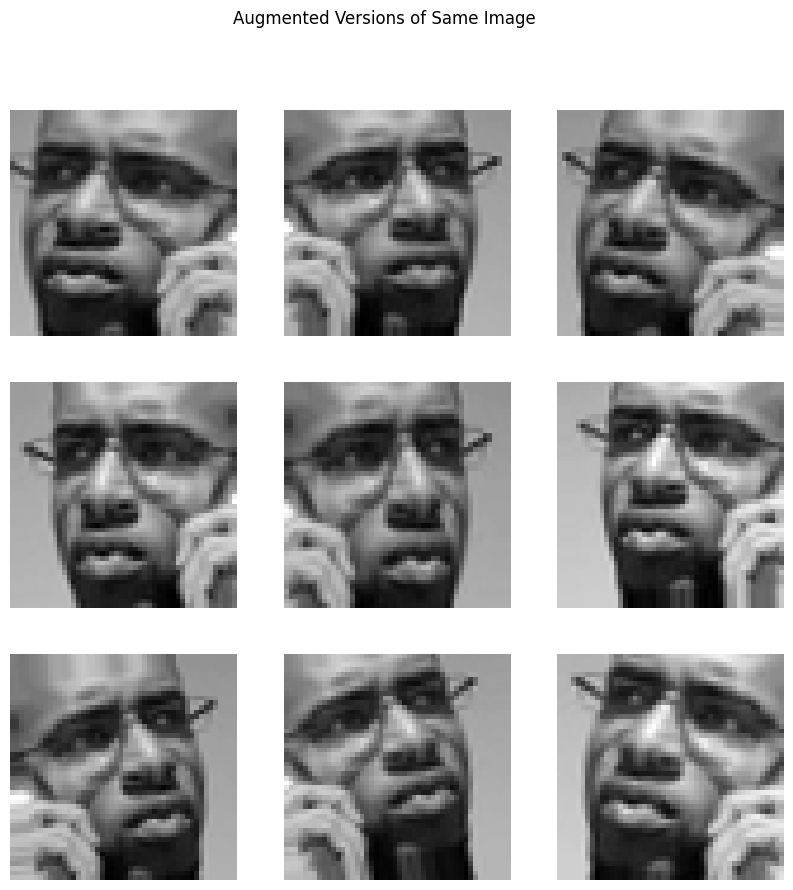

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i in range(9):

    augmented_image = next(augmented_iterator)[0]

    plt.subplot(3,3,i+1)

    plt.imshow(
        augmented_image.squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Augmented Versions of Same Image")

plt.show()

# Class Distribution Analysis

FER2013 is known to have class imbalance, particularly for the disgust class.

Understanding the distribution helps interpret future evaluation metrics such as precision, recall, and F1 score.

In [ ]:
import pandas as pd

class_distribution = pd.Series(
    np.argmax(y_train, axis=1)
).value_counts().sort_index()

class_distribution

,count
0,3196
1,349
2,3277
3,5772
4,3972
5,3864
6,2537


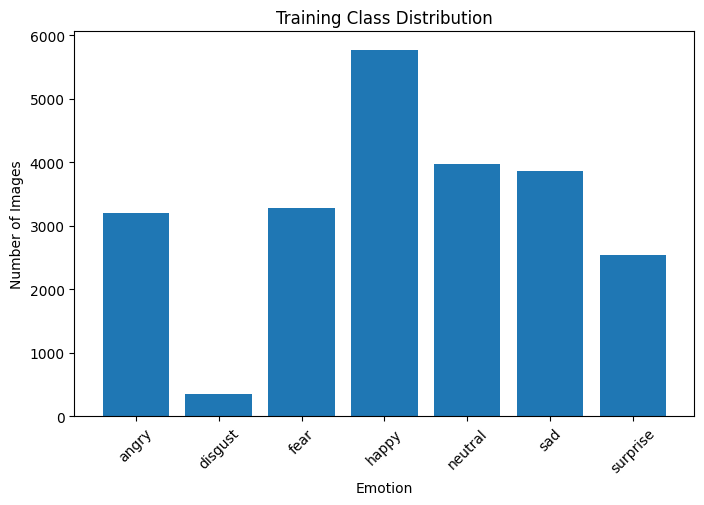

In [ ]:
emotion_names = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

plt.figure(figsize=(8,5))

plt.bar(
    emotion_names,
    class_distribution
)

plt.title("Training Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

## Findings

The dataset is imbalanced.

The disgust class contains significantly fewer examples than other emotions.

This may result in:

- Lower recall for disgust
- Lower F1 score for disgust
- More frequent misclassification

For this reason, accuracy alone will not be sufficient for evaluation.